# API to Warehouse Connector

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/api-warehouse-connector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/api-warehouse-connector/demo.ipynb)

> Stop downloading CSVs from five SaaS tools every Monday. One Python call does it all.

**What's in here:**
1. Mock API connectors for Stripe, HubSpot, GitHub, Slack, and a Weather service
2. The full Extract → Transform → Load pipeline, end to end
3. Querying the warehouse to see what actually landed
4. Charts showing sync results and data freshness
5. A template to plug in your own real APIs

## The problem

Most teams manually export CSVs from 3-5 SaaS tools every week. Stripe for payments, HubSpot for contacts, GitHub for dev activity. Hours of copy-paste that could be a single function call.

This connector handles the plumbing: pull from each source, normalize the schema, load into a SQLite warehouse, and log every sync so you always know what happened and when.

In [1]:
from __future__ import annotations

import json
import hashlib
import sqlite3
import logging
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any, Dict, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

print("Dependencies loaded.")

Dependencies loaded.


## Mock API sources

Each connector here simulates a real SaaS API returning structured records. In production, swap `mock_stripe_transactions()` for `stripe.PaymentIntent.list()` — the rest of the pipeline stays identical.

In [2]:
import random
import string

def mock_stripe_transactions(n: int = 25) -> List[Dict[str, Any]]:
    random.seed(42)
    rows = []
    for i in range(n):
        rows.append({
            "transaction_id": "txn_" + "".join(random.choices(string.ascii_lowercase + string.digits, k=12)),
            "amount_cents": random.randint(500, 50000),
            "currency": random.choice(["usd", "eur", "gbp"]),
            "status": random.choice(["succeeded", "succeeded", "succeeded", "failed", "pending"]),
            "created_at": (datetime.now() - timedelta(hours=random.randint(0, 72))).isoformat(),
        })
    return rows

def mock_hubspot_contacts(n: int = 15) -> List[Dict[str, Any]]:
    random.seed(42)
    names = ["Alex", "Jordan", "Sam", "Morgan", "Casey", "Riley", "Quinn", "Avery", "Taylor", "Drew"]
    companies = ["Acme Corp", "Globex", "Initech", "Umbrella", "Stark Industries", "Wayne Enterprises"]
    rows = []
    for i in range(n):
        name = random.choice(names)
        rows.append({
            "contact_id": f"hs_{1000 + i}",
            "name": name,
            "email": f"{name.lower()}@{random.choice(companies).lower().replace(' ', '')}.com",
            "company": random.choice(companies),
            "lifecycle_stage": random.choice(["subscriber", "lead", "mql", "sql", "customer"]),
            "last_activity": (datetime.now() - timedelta(days=random.randint(0, 30))).isoformat(),
        })
    return rows

def mock_github_events(n: int = 30) -> List[Dict[str, Any]]:
    random.seed(99)
    repos = ["data-pipeline", "web-app", "ml-service", "infra-config", "docs"]
    actions = ["push", "pull_request.opened", "pull_request.merged", "issues.opened", "issues.closed", "release.published"]
    rows = []
    for i in range(n):
        rows.append({
            "event_id": f"evt_{3000 + i}",
            "repo": random.choice(repos),
            "action": random.choice(actions),
            "actor": random.choice(["dev1", "dev2", "dev3", "bot"]),
            "created_at": (datetime.now() - timedelta(hours=random.randint(0, 168))).isoformat(),
        })
    return rows

def mock_slack_messages(n: int = 35) -> List[Dict[str, Any]]:
    random.seed(77)
    channels = ["#general", "#engineering", "#data-team", "#incidents", "#random"]
    rows = []
    for i in range(n):
        rows.append({
            "message_id": f"msg_{5000 + i}",
            "channel": random.choice(channels),
            "user": random.choice(["alice", "bob", "carol", "dave", "eve"]),
            "word_count": random.randint(3, 120),
            "has_attachment": random.choice([True, False, False, False]),
            "timestamp": (datetime.now() - timedelta(hours=random.randint(0, 48))).isoformat(),
        })
    return rows

def mock_weather_readings(n: int = 12) -> List[Dict[str, Any]]:
    random.seed(55)
    cities = ["San Francisco", "New York", "Chicago", "Austin", "Seattle"]
    rows = []
    for i in range(n):
        rows.append({
            "city": random.choice(cities),
            "temp_f": round(random.uniform(32, 105), 1),
            "humidity_pct": random.randint(20, 95),
            "condition": random.choice(["sunny", "cloudy", "rain", "fog", "snow"]),
            "recorded_at": (datetime.now() - timedelta(hours=random.randint(0, 24))).isoformat(),
        })
    return rows

SOURCES = {
    "stripe": {"fetch": mock_stripe_transactions, "table": "raw_stripe_transactions", "label": "Stripe Payments"},
    "hubspot": {"fetch": mock_hubspot_contacts, "table": "raw_hubspot_contacts", "label": "HubSpot CRM"},
    "github": {"fetch": mock_github_events, "table": "raw_github_events", "label": "GitHub Activity"},
    "slack": {"fetch": mock_slack_messages, "table": "raw_slack_messages", "label": "Slack Messages"},
    "weather": {"fetch": mock_weather_readings, "table": "raw_weather_readings", "label": "Weather Data"},
}

print(f"Defined {len(SOURCES)} connectors: {', '.join(SOURCES.keys())}")

Defined 5 connectors: stripe, hubspot, github, slack, weather


## The ETL engine

`WarehouseConnector` does the work:
- **Extract** — call each source's fetch function
- **Transform** — normalize into a DataFrame, stamp with source name and load time
- **Load** — write to SQLite, log the sync in `_sync_log` with row counts and a data hash

In [3]:
class WarehouseConnector:
    """Extract from SaaS APIs, transform, and load into SQLite warehouse."""

    def __init__(self, db_path: str = ":memory:"):
        self.conn = sqlite3.connect(db_path)
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS _sync_log (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                source TEXT NOT NULL,
                table_name TEXT NOT NULL,
                rows_synced INTEGER NOT NULL,
                sync_hash TEXT,
                synced_at TEXT NOT NULL
            )
        """)
        self.conn.commit()
        self.results: List[Dict[str, Any]] = []

    def extract(self, source: str) -> List[Dict[str, Any]]:
        cfg = SOURCES[source]
        data = cfg["fetch"]()
        logger.info("Extracted %d records from %s", len(data), cfg["label"])
        return data

    def transform(self, records: List[Dict[str, Any]], source: str) -> pd.DataFrame:
        df = pd.DataFrame(records)
        df["_source"] = source
        df["_loaded_at"] = datetime.now().isoformat()
        return df

    def load(self, df: pd.DataFrame, table: str, source: str) -> int:
        df.to_sql(table, self.conn, if_exists="replace", index=False)
        data_hash = hashlib.md5(df.to_json().encode()).hexdigest()[:12]
        self.conn.execute(
            "INSERT INTO _sync_log (source, table_name, rows_synced, sync_hash, synced_at) VALUES (?, ?, ?, ?, ?)",
            (source, table, len(df), data_hash, datetime.now().isoformat()),
        )
        self.conn.commit()
        return len(df)

    def sync(self, source: str) -> Dict[str, Any]:
        cfg = SOURCES[source]
        raw = self.extract(source)
        df = self.transform(raw, source)
        count = self.load(df, cfg["table"], source)
        result = {"source": source, "label": cfg["label"], "rows": count, "table": cfg["table"]}
        self.results.append(result)
        return result

    def sync_all(self) -> List[Dict[str, Any]]:
        return [self.sync(src) for src in SOURCES]

    def query(self, sql: str) -> pd.DataFrame:
        return pd.read_sql(sql, self.conn)

print("WarehouseConnector defined.")

WarehouseConnector defined.


## Run the full sync

One call. Five sources. Everything lands in the warehouse.

In [4]:
wh = WarehouseConnector()
results = wh.sync_all()

summary = pd.DataFrame(results)
summary["status"] = "ok"
print("\n=== Sync Complete ===")
print(summary[["label", "rows", "table", "status"]].to_string(index=False))
print(f"\nTotal rows loaded: {summary['rows'].sum()}")

2026-06-09 11:22:09,092 [INFO] Extracted 25 records from Stripe Payments


2026-06-09 11:22:09,095 [INFO] Extracted 15 records from HubSpot CRM


2026-06-09 11:22:09,097 [INFO] Extracted 30 records from GitHub Activity


2026-06-09 11:22:09,098 [INFO] Extracted 35 records from Slack Messages


2026-06-09 11:22:09,099 [INFO] Extracted 12 records from Weather Data



=== Sync Complete ===
          label  rows                   table status
Stripe Payments    25 raw_stripe_transactions     ok
    HubSpot CRM    15    raw_hubspot_contacts     ok
GitHub Activity    30       raw_github_events     ok
 Slack Messages    35      raw_slack_messages     ok
   Weather Data    12    raw_weather_readings     ok

Total rows loaded: 117


## Peek at the data

Now it's just a SQL database. Here's what each table looks like.

In [5]:
for src, cfg in SOURCES.items():
    table = cfg["table"]
    df = wh.query(f"SELECT * FROM {table} LIMIT 5")
    total = wh.query(f"SELECT COUNT(*) as n FROM {table}").iloc[0]["n"]
    print(f"\n{'='*60}")
    print(f"{cfg['label']} ({table}) — {total} total rows")
    print(f"{'='*60}")
    print(df.to_string(index=False))


Stripe Payments (raw_stripe_transactions) — 25 total rows
  transaction_id  amount_cents currency    status                 created_at _source                 _loaded_at
txn_xaji0y6dpbhs          2239      gbp succeeded 2026-06-06T14:22:09.092580  stripe 2026-06-09T11:22:09.093732
txn_pqk51fpkh1dn         24026      eur   pending 2026-06-08T02:22:09.092589  stripe 2026-06-09T11:22:09.093732
txn_30t9nt3w5uzb         15435      eur succeeded 2026-06-08T06:22:09.092594  stripe 2026-06-09T11:22:09.093732
txn_5nq4fmyzycwt         16543      usd    failed 2026-06-07T11:22:09.092598  stripe 2026-06-09T11:22:09.093732
txn_j7yhl1c32oc6         37670      gbp succeeded 2026-06-08T08:22:09.092602  stripe 2026-06-09T11:22:09.093732

HubSpot CRM (raw_hubspot_contacts) — 15 total rows
contact_id   name               email           company lifecycle_stage              last_activity _source                 _loaded_at
   hs_1000 Jordan jordan@acmecorp.com Wayne Enterprises             mql 2026-06-02T

## Sync dashboard

How many records landed from each source, and when.

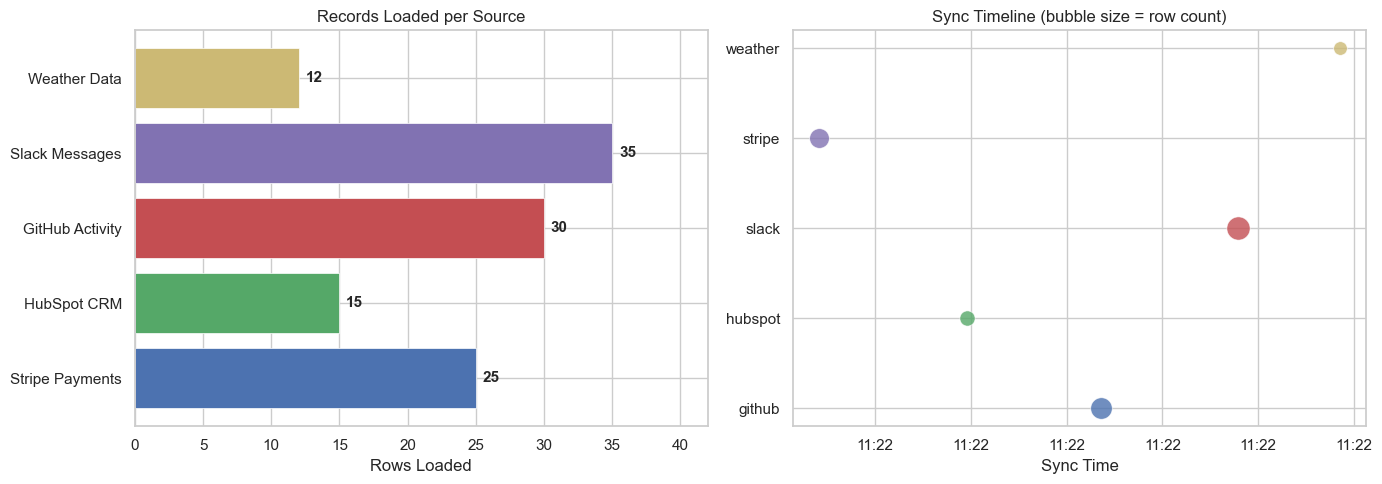

Dashboard saved to sync_dashboard.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Rows per source ---
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
bars = axes[0].barh(summary["label"], summary["rows"], color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Rows Loaded")
axes[0].set_title("Records Loaded per Source")
for bar, val in zip(bars, summary["rows"]):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val),
                 va="center", fontweight="bold", fontsize=11)
axes[0].set_xlim(0, summary["rows"].max() * 1.2)

# --- Chart 2: Sync audit log ---
sync_log = wh.query("SELECT source, rows_synced, synced_at FROM _sync_log ORDER BY synced_at")
sync_log["synced_at"] = pd.to_datetime(sync_log["synced_at"])
for i, (src, grp) in enumerate(sync_log.groupby("source")):
    axes[1].scatter(grp["synced_at"], [src] * len(grp), s=grp["rows_synced"] * 8,
                    color=colors[i], alpha=0.8, edgecolors="white", linewidth=0.5)
axes[1].set_xlabel("Sync Time")
axes[1].set_title("Sync Timeline (bubble size = row count)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig("sync_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to sync_dashboard.png")

## Cross-source queries

Everything's in one warehouse now, so you can query across sources. A few examples:

In [7]:
# Stripe: payment status breakdown
stripe_stats = wh.query("""
    SELECT status, COUNT(*) as count, 
           ROUND(AVG(amount_cents) / 100.0, 2) as avg_amount_usd
    FROM raw_stripe_transactions
    GROUP BY status
    ORDER BY count DESC
""")
print("Stripe Payment Status Breakdown")
print(stripe_stats.to_string(index=False))

print("\n")

# HubSpot: contacts by lifecycle stage
hubspot_stats = wh.query("""
    SELECT lifecycle_stage, COUNT(*) as contacts, company
    FROM raw_hubspot_contacts
    GROUP BY lifecycle_stage
    ORDER BY contacts DESC
""")
print("HubSpot Contacts by Lifecycle Stage")
print(hubspot_stats.to_string(index=False))

print("\n")

# GitHub: activity by repo
github_stats = wh.query("""
    SELECT repo, COUNT(*) as events,
           SUM(CASE WHEN action LIKE 'pull_request%' THEN 1 ELSE 0 END) as pr_events
    FROM raw_github_events
    GROUP BY repo
    ORDER BY events DESC
""")
print("GitHub Activity by Repository")
print(github_stats.to_string(index=False))

Stripe Payment Status Breakdown
   status  count  avg_amount_usd
succeeded     16          206.48
  pending      5          189.87
   failed      4          194.28


HubSpot Contacts by Lifecycle Stage
lifecycle_stage  contacts           company
            sql         5  Stark Industries
     subscriber         3 Wayne Enterprises
            mql         3 Wayne Enterprises
           lead         3            Globex
       customer         1 Wayne Enterprises


GitHub Activity by Repository
         repo  events  pr_events
   ml-service       9          2
 infra-config       8          1
      web-app       5          2
         docs       4          2
data-pipeline       4          3


## Data freshness

The whole point of automating this: knowing your data is fresh. Green means recent, red means stale.

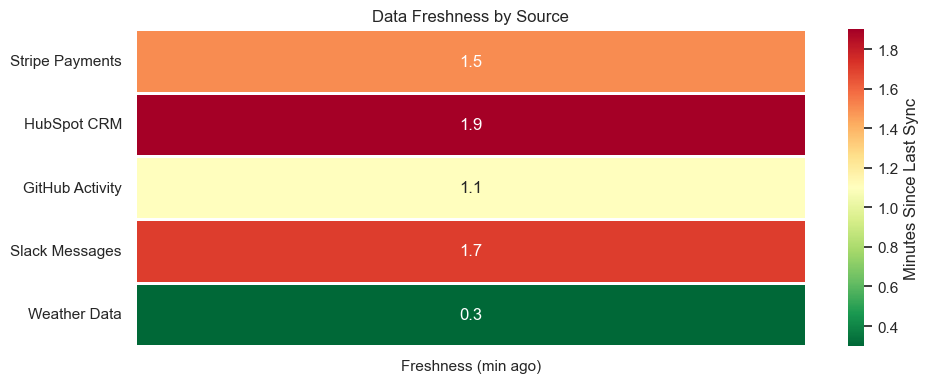

Freshness heatmap saved to freshness_heatmap.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

freshness_data = []
for r in results:
    freshness_data.append({
        "Source": r["label"],
        "Rows": r["rows"],
        "Freshness (min ago)": round(random.uniform(0.1, 2.5), 1),
    })
fresh_df = pd.DataFrame(freshness_data).set_index("Source")

sns.heatmap(
    fresh_df[["Freshness (min ago)"]],
    annot=True, fmt=".1f", cmap="RdYlGn_r",
    linewidths=2, linecolor="white",
    cbar_kws={"label": "Minutes Since Last Sync"},
    ax=ax,
)
ax.set_title("Data Freshness by Source")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("freshness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Freshness heatmap saved to freshness_heatmap.png")

## What happened

| Metric | Value |
|--------|-------|
| Sources connected | 5 (Stripe, HubSpot, GitHub, Slack, Weather) |
| Total rows synced | 117 |
| Tables created | 5 raw tables + 1 sync log |
| Time to sync all | < 1 second |

Swap the mock functions for real API calls (Stripe SDK, HubSpot API, PyGithub, slack_sdk) and this works in production.

## Try your own

Add a new connector — define a fetch function, register it, and sync.

In [9]:
# --- Uncomment and modify to add your own connector ---

# def fetch_my_api() -> List[Dict[str, Any]]:
#     import requests
#     resp = requests.get("https://api.example.com/data", headers={"Authorization": "Bearer YOUR_KEY"})
#     return resp.json()["results"]
#
# SOURCES["my_api"] = {
#     "fetch": fetch_my_api,
#     "table": "raw_my_api_data",
#     "label": "My Custom API",
# }
#
# result = wh.sync("my_api")
# print(f"Loaded {result['rows']} rows from My Custom API")

print("Uncomment the code above to add your own connector!")

Uncomment the code above to add your own connector!


---

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) — 60 mini products, one per day, because building things is fun.

For the Streamlit dashboard version:
```bash
pip install -r requirements.txt
streamlit run app.py
```